# 04 · Model Evaluation

Loads the trained model and assesses performance on the held-out test set.

Metrics reported:
- Overall accuracy
- Per-class precision / recall / F1
- Confusion matrix

In [7]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from src.features.engineering import FEATURE_COLUMNS
from src.models.predict import (
    load_model, prepare_training_data,
    evaluate_model, plot_confusion_matrix,
)
from src.features.engineering import FEATURE_COLUMNS, LABEL_MAP, INV_LABEL_MAP

PROCESSED_PATH = pathlib.Path("../data/processed/matches_features.csv")
MODEL_PATH     = pathlib.Path("../models/rf_match_predict_model.pkl")

## Load data & model

In [13]:
df    = pd.read_csv(PROCESSED_PATH, parse_dates=["Date"])
model = load_model(MODEL_PATH)

## Reconstruct the same train / test split

In [8]:
df = pd.read_csv(PROCESSED_PATH, parse_dates=["Date"])
print(f"Dataset: {len(df):,} matches")
print(f"Outcomes:\n{df['FTR'].value_counts().to_dict()}\n")

X = df[FEATURE_COLUMNS].astype("float32")
y = df["FTR"].map(LABEL_MAP)

# First split: 90% for training+validation, 10% for test (held out)
# Using same seed as 03 notebook so hoping the test set is the same as before for a fair comparison
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

Dataset: 15,072 matches
Outcomes:
{'H': 6959, 'A': 4409, 'D': 3704}



## Accuracy & classification report

In [9]:
results = evaluate_model(model, X_test, y_test)
print(f"Test accuracy: {results['accuracy']:.4f}\n")
print(results["report"])

Test accuracy: 0.5345

              precision    recall  f1-score   support

           H       0.57      0.78      0.66       696
           D       0.33      0.03      0.05       371
           A       0.49      0.57      0.53       441

    accuracy                           0.53      1508
   macro avg       0.46      0.46      0.41      1508
weighted avg       0.49      0.53      0.47      1508



## Confusion matrix

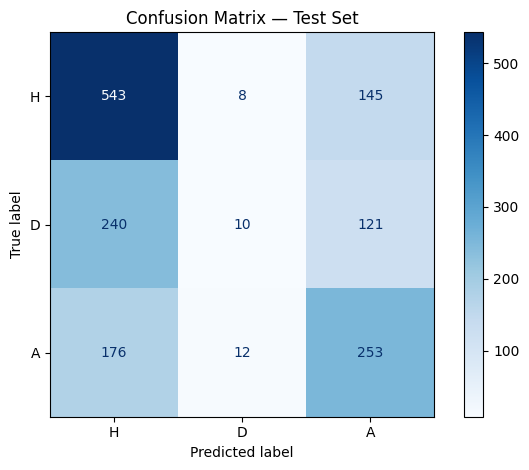

In [10]:
disp = plot_confusion_matrix(results)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

## ROC Curves (One-vs-Rest, Test Set)

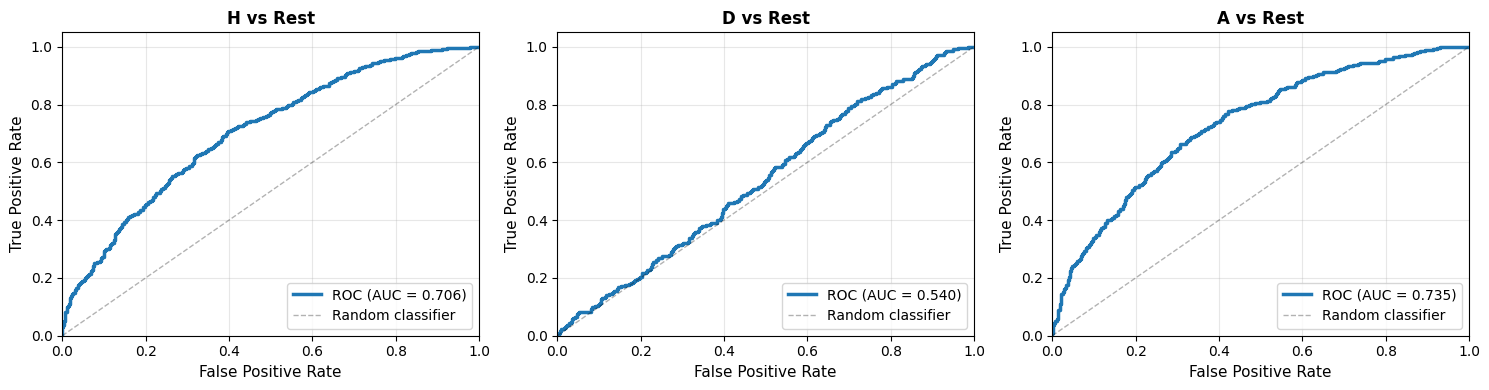

In [14]:
from sklearn.metrics import roc_curve, auc

# Get probability predictions
probas = model.predict_proba(X_test.fillna(0).astype("float32"))

# Plot ROC curves for each class
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
target_names = [INV_LABEL_MAP[i] for i in sorted(INV_LABEL_MAP)]

for idx, (ax, i) in enumerate(zip(axes, sorted(INV_LABEL_MAP))):
    # Binary classification: class i vs rest
    y_true_binary = (y_test == i).astype(int)
    y_proba = probas[:, i]
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_true_binary, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Plot
    ax.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'ROC (AUC = {roc_auc:.3f})')
    ax.plot([0, 1], [0, 1], color='k', lw=1, linestyle='--', alpha=0.3, label='Random classifier')
    
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{target_names[idx]} vs Rest', fontsize=12, fontweight='bold')
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Probability calibration (reliability diagram)

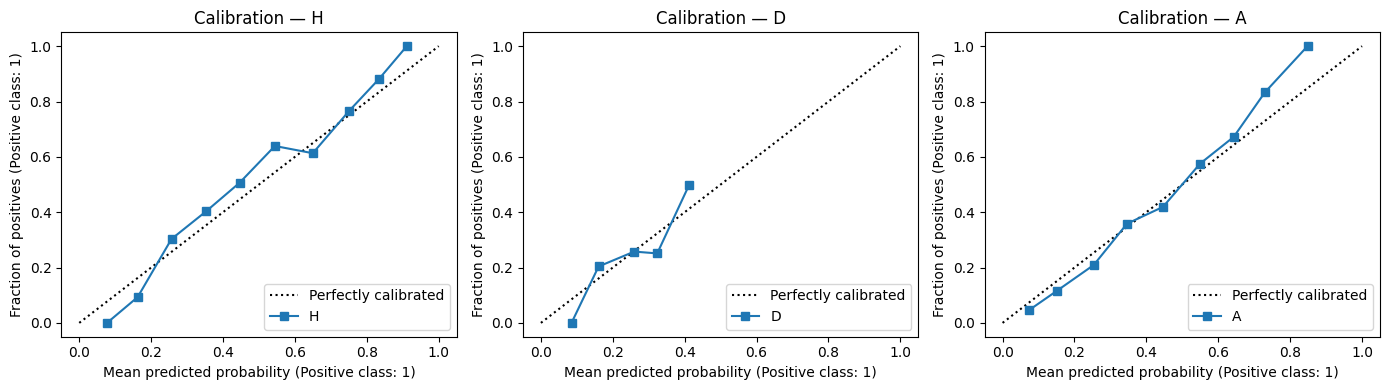

In [15]:
from sklearn.calibration import CalibrationDisplay
from src.features.engineering import LABEL_MAP, INV_LABEL_MAP
import numpy as np

probas = model.predict_proba(X_test.fillna(0).astype("float32"))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, ax in enumerate(axes):
    CalibrationDisplay.from_predictions(
        (y_test == i).astype(int),
        probas[:, i],
        n_bins=10,
        ax=ax,
        name=INV_LABEL_MAP[i],
    )
    ax.set_title(f"Calibration — {INV_LABEL_MAP[i]}")
plt.tight_layout()
plt.show()

## Temporal performance (accuracy by season)

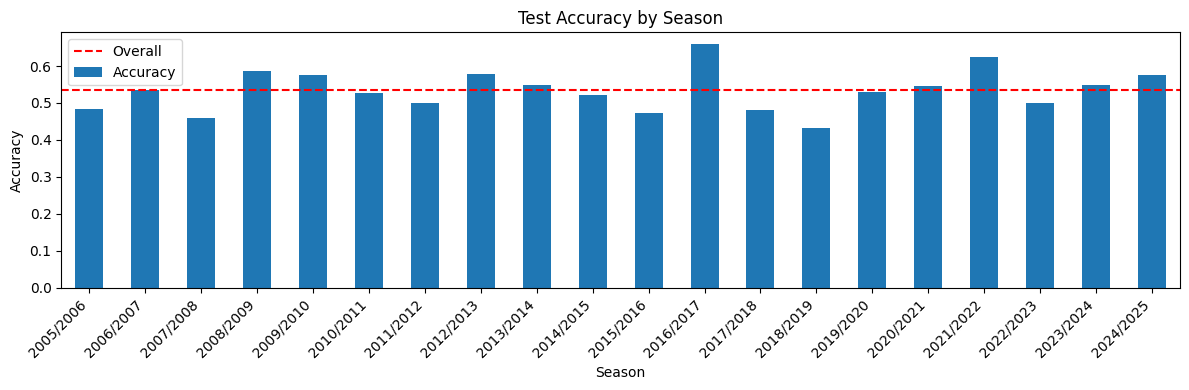

,Season,Accuracy
0,2005/2006,0.484375
1,2006/2007,0.534483
2,2007/2008,0.458824
3,2008/2009,0.585714
4,2009/2010,0.576471
5,2010/2011,0.525641
6,2011/2012,0.500000
7,2012/2013,0.579710
8,2013/2014,0.549296
9,2014/2015,0.522222


In [12]:
test_df = df.loc[X_test.index, ["Season", "FTR"]].copy()
test_df["Predicted"] = model.predict(X_test.fillna(0).astype("float32"))
test_df["Predicted"] = test_df["Predicted"].map(LABEL_MAP.__class__(zip(LABEL_MAP.values(), LABEL_MAP.keys())))

from src.features.engineering import INV_LABEL_MAP
test_df["Predicted"] = model.predict(X_test.fillna(0).astype("float32"))
test_df["Predicted"] = [INV_LABEL_MAP[int(p)] for p in test_df["Predicted"]]
test_df["Correct"] = test_df["FTR"] == test_df["Predicted"]

season_acc = test_df.groupby("Season")["Correct"].mean().reset_index()
season_acc.columns = ["Season", "Accuracy"]
season_acc.plot(x="Season", y="Accuracy", kind="bar", figsize=(12, 4), legend=False)
plt.ylabel("Accuracy")
plt.title("Test Accuracy by Season")
plt.xticks(rotation=45, ha="right")
plt.axhline(results["accuracy"], color="red", linestyle="--", label="Overall")
plt.legend()
plt.tight_layout()
plt.show()
season_acc